Nombre: Felipe Aravena
Rut: 21.128.400-5
Fecha: 22-04-2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



Se carga el dataset `encuesta_salud.csv` y se realiza una inspección general para conocer su estructura, tipos de datos y valores faltantes.


In [2]:
# Carga del dataset
df = pd.read_csv('encuesta_salud.csv')

print("=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

print("\n=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(df.describe())

print("\n=== VALORES FALTANTES POR COLUMNA ===")
nan_counts = df.isnull().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
nan_df = pd.DataFrame({'NaN': nan_counts, '% del total': nan_pct})
display(nan_df[nan_df['NaN'] > 0])

print("\n=== RANGO DE talla_m ===")
print(f"Mínimo: {df['talla_m'].min():.2f}  |  Máximo: {df['talla_m'].max():.2f}")
print(f"Registros con talla_m > 3 (probablemente en cm): {(df['talla_m'] > 3).sum()}")


=== FORMA DEL DATASET ===
Filas: 500 | Columnas: 10

=== PRIMERAS FILAS ===


,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa,grupo_sanguineo,region,diagnostico
0,1,56.00,86.80,1.80,124.80,231.00,77.50,B-,Araucania,Sano
1,2,69.00,72.70,1.46,104.40,148.90,102.50,A+,Biobio,Hipertension
2,3,46.00,84.20,1.50,164.50,220.30,78.30,AB+,Valparaiso,Hipertension
3,4,32.00,86.90,1.63,95.20,218.40,60.50,AB-,Araucania,Prediabetes
4,5,NaN,58.60,1.78,130.50,152.60,400.00,B-,Biobio,Sano



=== TIPOS DE DATOS ===
id                    int64
edad                float64
peso_kg             float64
talla_m             float64
presion_arterial    float64
colesterol          float64
glucosa             float64
grupo_sanguineo         str
region                  str
diagnostico             str
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS ===


,id,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,500.00,455.00,440.00,500.00,500.00,460.00,500.00
mean,250.50,50.18,72.44,6.76,123.15,193.66,101.81
std,144.48,18.21,14.32,28.92,29.66,34.47,47.26
min,1.00,18.00,34.80,1.33,62.20,102.60,18.60
25%,125.75,35.00,63.27,1.61,106.35,170.15,80.38
50%,250.50,50.00,72.35,1.69,120.75,193.95,97.45
75%,375.25,66.00,82.93,1.75,133.68,217.05,112.80
max,500.00,79.00,111.00,186.00,290.00,290.60,420.00



=== VALORES FALTANTES POR COLUMNA ===


,NaN,% del total
edad,45,9.00
peso_kg,60,12.00
colesterol,40,8.00
grupo_sanguineo,25,5.00
diagnostico,30,6.00



=== RANGO DE talla_m ===
Mínimo: 1.33  |  Máximo: 186.00
Registros con talla_m > 3 (probablemente en cm): 15


Filas  500 
Columnas 10
Tipos de datos `float64` (numéricas), `object` (categóricas) 

Columnas con valores faltantes:
edad – 45 NaN 
peso_kg - 60 NaN 
colesterol  – 40 NaN 
grupo_sanguineo – 25 NaN 
diagnostico` – 30 NaN 

Error detectado en `talla_m`: existen registros con valores entre 160 y 186, lo que indica que fueron ingresados en centímetros en lugar de metros. Deben dividirse por 100.


Se usa la mediana por ser robusta ante valores extremos (outliers presentes en el dataset)
for col in ['edad', 'peso_kg', 'colesterol']:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"'{col}' → imputado con mediana = {mediana:.2f}")

Imputación de variables categóricas con la moda 
for col in ['grupo_sanguineo', 'diagnostico']:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f"'{col}' → imputado con moda = '{moda}'")

2.4 Verificación 
print("\n=== NaN RESTANTES ===")
print(df.isnull().sum())
assert df.isnull().sum().sum() == 0, "¡Aún hay valores faltantes!"
print("\nTodas las columnas tienen 0 valores faltantes.")


In [3]:
# ── 2.1 Corrección de talla_m en centímetros ────────────────────────────────
print(f"Registros con talla_m > 3 ANTES: {(df['talla_m'] > 3).sum()}")
mask = df['talla_m'] > 3
df['talla_m'] = df['talla_m'].where(~mask, df['talla_m'] / 100)
print(f"Registros con talla_m > 3 DESPUÉS: {(df['talla_m'] > 3).sum()}")
print(f"Nuevo rango talla_m: [{df['talla_m'].min():.2f}, {df['talla_m'].max():.2f}]")


Registros con talla_m > 3 ANTES: 15
Registros con talla_m > 3 DESPUÉS: 0
Nuevo rango talla_m: [1.33, 1.98]


In [4]:
# Se usa la mediana por ser robusta ante valores extremos (outliers presentes en el dataset)
# Trabajamos sobre una copia explícita para evitar problemas de Copy-on-Write
df = df.copy()

for col in ['edad', 'peso_kg', 'colesterol']:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"'{col}' → imputado con mediana = {mediana:.2f}")

#  Imputación de variables categóricas con la moda
for col in ['grupo_sanguineo', 'diagnostico']:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)
    print(f"'{col}' → imputado con moda = '{moda}'")

# Verificación 
print("\n=== NaN RESTANTES ===")
print(df.isnull().sum())
assert df.isnull().sum().sum() == 0, "¡Aún hay valores faltantes!"
print("\nTodas las columnas tienen 0 valores faltantes.")


'edad' → imputado con mediana = 50.00
'peso_kg' → imputado con mediana = 72.35
'colesterol' → imputado con mediana = 193.95
'grupo_sanguineo' → imputado con moda = 'AB-'
'diagnostico' → imputado con moda = 'Obesidad'

=== NaN RESTANTES ===
id                  0
edad                0
peso_kg             0
talla_m             0
presion_arterial    0
colesterol          0
glucosa             0
grupo_sanguineo     0
region              0
diagnostico         0
dtype: int64

Todas las columnas tienen 0 valores faltantes.


Decisiones de Imputación – Actividad 2

edad | Numérica continua | Mediana| Robusta ante la presencia de outliers; no distorsiona la distribución como lo haría la media. |
peso_kg | Numérica continua | Mediana | Misma razón que `edad`; el peso puede tener asimetría. |
colesterol | Numérica continua | **Mediana | Colesterol puede ser asimétrico (valores muy altos posibles). |
grupo_sanguineo | Categórica nominal | Moda | Para variables sin orden, la categoría más frecuente es la mejor estimación puntual. |
diagnostico` | Categórica ordinal | Moda | Al ser <6 % de registros, imputar con la clase más frecuente introduce poco sesgo. |
talla_m | Error de escala | Dividir /100 | Los valores > 3 estaban en centímetros; se corrigen antes de imputar. |


Ejercicio 3: Detección y Manejo de Outliers
Se aplican dos métodos complementarios: IQR (no paramétrico) para presion_arterial y Z-Score para glucosa.


In [5]:
#Método IQR – presion_arterial 
Q1  = df['presion_arterial'].quantile(0.25)
Q3  = df['presion_arterial'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {IQR:.1f}")
print(f"Límite inferior: {lim_inf:.1f}")
print(f"Límite superior: {lim_sup:.1f}")

outliers = df[(df['presion_arterial'] < lim_inf) | (df['presion_arterial'] > lim_sup)]
print(f"\nOutliers detectados: {len(outliers)}")
if len(outliers) > 0:
    display(outliers[['id', 'presion_arterial', 'diagnostico']])


Q1: 106.4 | Q3: 133.7 | IQR: 27.3
Límite inferior: 65.4
Límite superior: 174.7

Outliers detectados: 15


,id,presion_arterial,diagnostico
47,48,260.00,Sano
49,50,220.00,Hipertension
71,72,275.00,Obesidad
108,109,62.20,Obesidad
148,149,275.00,Diabetes
260,261,290.00,Obesidad
300,301,64.50,Prediabetes
314,315,250.00,Obesidad
336,337,62.60,Hipertension
350,351,250.00,Hipertension


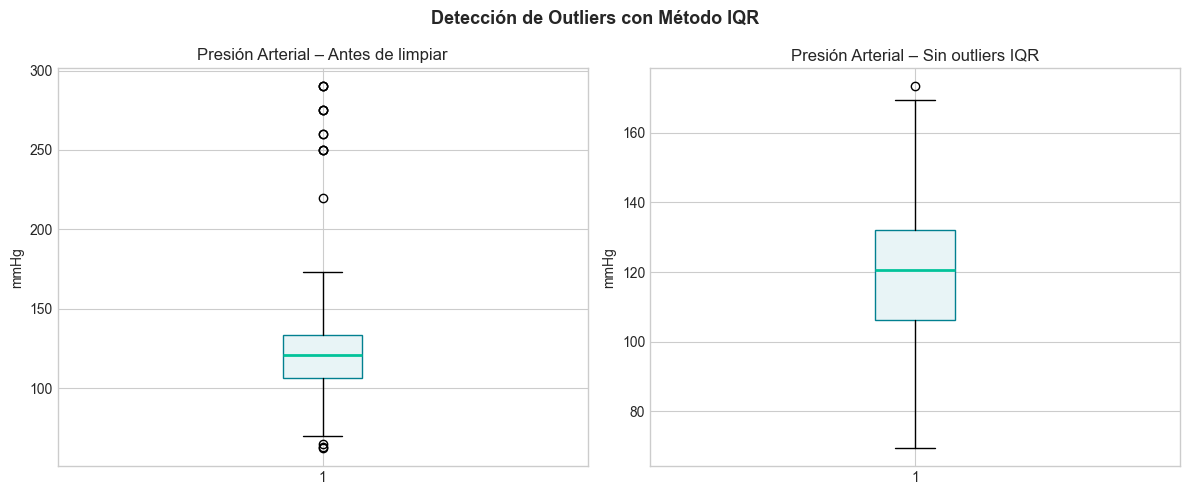

Filas restantes tras eliminar outliers IQR: 485


In [6]:
#  Boxplot comparativo – presion_arterial
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['presion_arterial'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E8F4F6', color='#028090'),
                medianprops=dict(color='#02C39A', linewidth=2))
axes[0].set_title('Presión Arterial – Antes de limpiar', fontsize=12)
axes[0].set_ylabel('mmHg')

# Filtrar outliers IQR
df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]

axes[1].boxplot(df_limpio['presion_arterial'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E8F4F6', color='#028090'),
                medianprops=dict(color='#02C39A', linewidth=2))
axes[1].set_title('Presión Arterial – Sin outliers IQR', fontsize=12)
axes[1].set_ylabel('mmHg')

plt.suptitle('Detección de Outliers con Método IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_presion.png', dpi=150, bbox_inches='tight')
plt.show()

# Actualizar df
df = df_limpio.copy()
print(f"Filas restantes tras eliminar outliers IQR: {len(df)}")


In [7]:
#3.3 Método Z-Score – glucosa 
z_scores   = np.abs(stats.zscore(df['glucosa']))
outliers_z = df[z_scores > 3]

print(f"Outliers por Z-Score en glucosa (|z| > 3): {len(outliers_z)}")
if len(outliers_z) > 0:
    display(outliers_z[['id', 'glucosa']])

# Eliminar outliers Z-Score
df = df[z_scores <= 3].copy()
print(f"Filas restantes tras eliminar outliers Z-Score: {len(df)}")


Outliers por Z-Score en glucosa (|z| > 3): 10


,id,glucosa
4,5,400.00
5,6,400.00
26,27,400.00
111,112,400.00
180,181,400.00
283,284,380.00
290,291,380.00
303,304,420.00
304,305,380.00
443,444,400.00


Filas restantes tras eliminar outliers Z-Score: 475


Reflexión – Actividad 3

¿Sería correcto eliminar valores extremos de presión arterial que representan pacientes con hipertensión severa?

No necesariamente. Depende del objetivo del análisis:

- Si el objetivo es construir un modelo predictivo general, eliminar estos valores puede ser justificado para evitar que el modelo se sesgue hacia casos extremos poco representativos.
- Sin embargo, si el dataset proviene de un contexto clínico donde la hipertensión severa es el fenómeno de interés, eliminar esos registros sería un error grave: se perdería información crítica y el modelo resultante no sería generalizable a la población que más necesita predicción.

Recomendación práctica: en lugar de eliminar, considerar técnicas como *winsorización* (reemplazar extremos por los límites del IQR) o mantener los valores y documentarlos como casos clínicos válidos, separando el análisis exploratorio del modelado.


Ejercicio 4: Normalización de Variables Numéricas
Se aplica Min-Max Scaling para transformar todas las variables numéricas al rango [0, 1], necesario antes de aplicar modelos sensibles a la magnitud (k-NN, SVM, PCA).


In [8]:
#Min-Max Scaling 
cols_numericas = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']

scaler_mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[cols_numericas] = scaler_mm.fit_transform(df[cols_numericas])

print("Estadísticas tras Min-Max Scaling:")
display(df_minmax[cols_numericas].describe().round(3))

# Verificación: todos los valores deben estar en [0, 1]
assert df_minmax[cols_numericas].min().min() >= 0.0, "Valor menor a 0 detectado"
assert df_minmax[cols_numericas].max().max() <= 1.0, "Valor mayor a 1 detectado"
print("\n Todos los valores están en el rango [0, 1].")


Estadísticas tras Min-Max Scaling:


,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,475.00,475.00,475.00,475.00,475.00,475.00
mean,0.53,0.49,0.54,0.49,0.48,0.58
std,0.28,0.18,0.15,0.18,0.18,0.16
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.33,0.40,0.43,0.36,0.37,0.46
50%,0.53,0.49,0.54,0.49,0.49,0.58
75%,0.77,0.61,0.65,0.60,0.59,0.70
max,1.00,1.00,1.00,1.00,1.00,1.00



 Todos los valores están en el rango [0, 1].


Verificación – Actividad 4

Tras aplicar `MinMaxScaler`, las estadísticas descriptivas confirman:
- min = 0.0 y max = 1.0 para todas las columnas numéricas seleccionadas.
- La media y desviación estándar se expresan ahora en escala relativa [0, 1].

Justificación de Min-Max sobre Standard Scaler: se prefiere cuando no se asume distribución normal y se quiere preservar la forma de la distribución original, siendo interpretable como "proporción del rango".


Ejercicio 5: Codificación de Variables Categóricas
Las variables categóricas deben convertirse a representación numérica para ser usadas en modelos. Se diferencian variables nominales (sin orden) de ordinales (con jerarquía).


In [9]:
# One-Hot Encoding – region y grupo_sanguineo (nominales)
df_final = df_minmax.copy()

# Guardamos dimensión inicial
cols_iniciales = df_final.shape[1]
print(f"Columnas ANTES de OHE: {cols_iniciales}")
print(list(df_final.columns))

df_final = pd.get_dummies(df_final, columns=['region'], drop_first=True)
df_final = pd.get_dummies(df_final, columns=['grupo_sanguineo'], drop_first=True)

print(f"\nColumnas DESPUÉS de OHE: {df_final.shape[1]}")
nuevas_cols = [c for c in df_final.columns if 'region_' in c or 'grupo_sanguineo_' in c]
print("Nuevas columnas generadas:")
print(nuevas_cols)


Columnas ANTES de OHE: 10
['id', 'edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa', 'grupo_sanguineo', 'region', 'diagnostico']

Columnas DESPUÉS de OHE: 19
Nuevas columnas generadas:
['region_Biobio', 'region_Metropolitana', 'region_OHiggins', 'region_Valparaiso', 'grupo_sanguineo_A-', 'grupo_sanguineo_AB+', 'grupo_sanguineo_AB-', 'grupo_sanguineo_B+', 'grupo_sanguineo_B-', 'grupo_sanguineo_O+', 'grupo_sanguineo_O-']


In [10]:
# Label Encoding – diagnostico (ordinal con jerarquía clínica) 
# Opción 1: Label Encoding automático
le = LabelEncoder()
df_final['diagnostico_cod'] = le.fit_transform(df_final['diagnostico'])

mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo Label Encoding (automático):")
print(mapeo)

# Opción 2: Mapeo manual con orden clínico explícito
mapeo_manual = {'Sano': 0, 'Prediabetes': 1, 'Diabetes': 2,
                'Hipertension': 3, 'Obesidad': 4}
df_final['diagnostico_manual'] = df_final['diagnostico'].map(mapeo_manual)

print("\nConteo de diagnósticos codificados:")
print(df_final['diagnostico_cod'].value_counts())

print(f"\nDimensiones del DataFrame final: {df_final.shape}")


Mapeo Label Encoding (automático):
{'Diabetes': np.int64(0), 'Hipertension': np.int64(1), 'Obesidad': np.int64(2), 'Prediabetes': np.int64(3), 'Sano': np.int64(4)}

Conteo de diagnósticos codificados:
diagnostico_cod
2    128
4     95
3     91
1     85
0     76
Name: count, dtype: int64

Dimensiones del DataFrame final: (475, 21)


Respuestas – Actividad 5

Columnas al inicio del ejercicio: 10 (originales del CSV).

Columnas al final: se agregan columnas producto del OHE de `region` (4 nuevas, con `drop_first`) y `grupo_sanguineo` (7 nuevas, con `drop_first`), más las 2 columnas de codificación de `diagnostico`.

¿Por qué drop_first=True? Elimina la primera categoría de cada variable dummy para evitar multicolinealidad perfecta: si hay `n` categorías, con `n-1` columnas binarias la información queda completamente representada.

¿Por qué Label Encoding para diagnostico y no OHE?** Porque diagnostico puede interpretarse con una jerarquía de severidad clínica (Sano → Prediabetes → Diabetes…). OHE trataría todas las categorías como igualmente distantes, lo cual no refleja la realidad clínica. El mapeo manual es preferible al automático por dar control explícito sobre el orden.


---
## Ejercicio 6: Reporte Final


In [11]:
#Resumen ejecutivo del pipeline 
print('=' * 60)
print('RESUMEN DEL PIPELINE DE LIMPIEZA - ENCUESTA SALUD')
print('=' * 60)
print(f'Filas originales:   500')
print(f'Filas finales:      {len(df_final)}')
print(f'Columnas originales: 10')
print(f'Columnas finales:   {len(df_final.columns)}')
print(f'Valores NaN restantes: {df_final.isnull().sum().sum()}')
print()
print('Columnas del DataFrame final:')
print(list(df_final.columns))


RESUMEN DEL PIPELINE DE LIMPIEZA - ENCUESTA SALUD
Filas originales:   500
Filas finales:      475
Columnas originales: 10
Columnas finales:   21
Valores NaN restantes: 0

Columnas del DataFrame final:
['id', 'edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa', 'diagnostico', 'region_Biobio', 'region_Metropolitana', 'region_OHiggins', 'region_Valparaiso', 'grupo_sanguineo_A-', 'grupo_sanguineo_AB+', 'grupo_sanguineo_AB-', 'grupo_sanguineo_B+', 'grupo_sanguineo_B-', 'grupo_sanguineo_O+', 'grupo_sanguineo_O-', 'diagnostico_cod', 'diagnostico_manual']


In [12]:
# Guardar dataset limpio 
df_final.to_csv('encuesta_salud_limpio.csv', index=False)
print('Dataset limpio guardado como encuesta_salud_limpio.csv')
print(f'Shape final: {df_final.shape}')


Dataset limpio guardado como encuesta_salud_limpio.csv
Shape final: (475, 21)


Reporte de Limpieza de Datos

1. Corrección de Escala
- Columna afectada: talla_m
- Problema: ~15 registros ingresados en centímetros (valores entre 160–186)
- Solución: dividir por 100 todos los registros con talla_m > 3

 2. Valores Faltantes
- Columnas afectadas: edad (9%), peso_kg (12%), colesterol (8%), grupo_sanguineo (5%), diagnostico (6%)
- Estrategia numérica: imputación con mediana → robusta ante outliers, no altera la distribución
- Estrategia categórica: imputación con moda → categoría más probable, porcentaje bajo de NaN

3. Outliers
- presion_arterial → Método IQR (no paramétrico): eliminados valores fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
- glucosa → Método Z-Score: eliminados registros con `|z| > 3` (más de 3 desviaciones estándar de la media)
- Reflexión: en contexto clínico real, los outliers de presión podrían representar pacientes con hipertensión severa; su eliminación debe justificarse según el objetivo del análisis

4. Normalización
- Técnica:** Min-Max Scaling x = (x − x_min) / (x_max − x_min)`
- Columnas:** edad, peso_kg, talla_m, presion_arterial, colesterol, glucosa
- Justificación:** transforma al rango [0,1] preservando la forma de la distribución; adecuado para k-NN, SVM y PCA

5. Codificación
| Variable | Tipo | Método | Razón |
|---|---|---|---|
| region | Nominal | OHE (drop_first=True) | Sin orden inherente; evita multicolinealidad |
| grupo_sanguineo | Nominal | OHE (drop_first=True) | Sin orden inherente |
| diagnostico | Ordinal | Label Encoding + mapeo manual | Jerarquía clínica Sano→Prediabetes→Diabetes… |
